In [1]:
import os, random, math, time
from pathlib import Path
from tqdm import tqdm
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.transforms import RandAugment
import timm

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [3]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from collections import Counter
from sklearn.manifold import TSNE
import cv2
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import graphviz
from graphviz import Digraph
import matplotlib.pyplot as plt
from torch.autograd import Function

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device == "cuda": torch.cuda.manual_seed_all(SEED)

Device: cuda


In [5]:
IMG_SIZE = 224
BATCH_SIZE = 8         # adjust if OOM
EPOCHS = 30
NUM_WORKERS = 4         # set 0 if worker issues on Kaggle
LR = 3e-4
LABEL_SMOOTH = 0.1
SAVE_PATH = "best_model.pth"
USE_SEGMENTATION = True

# Loss weights from PDF suggestion
ALPHA_DOM = 0.5
BETA_SUPCON = 0.3
ETA_CONS = 0.1
GAMMA_SEG = 0.5

# Mixup/CutMix probabilities and alphas
PROB_MIXUP = 0.5
PROB_CUTMIX = 0.5
MIXUP_ALPHA = 0.2
CUTMIX_ALPHA = 1.0

# warmup epochs
WARMUP_EPOCHS = 5

# early stopping
EARLY_STOPPING_PATIENCE = 20
FREEZE_EPOCHS = 5
ACCUMULATION_STEPS = 4

In [6]:
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=0.05):
        self.mean = mean
        self.std = std
    def __call__(self, tensor):
        noise = torch.randn(tensor.size()) * self.std + self.mean
        noisy_tensor = tensor + noise
        return torch.clamp(noisy_tensor, 0., 1.)
    def __repr__(self):
        return self.__class__.__name__ + f'(mean={self.mean}, std={self.std})'

weak_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    AddGaussianNoise(0., 0.02),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
strong_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ColorJitter(0.4,0.4,0.4,0.1),
    RandAugment(num_ops=2, magnitude=9),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    AddGaussianNoise(0., 0.05),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [7]:
# reading a file with multiple encodings
def read_file_with_encoding(file_path, encodings=['utf-8', 'utf-8-sig', 'ISO-8859-1']):
    """Tries to read a file using a list of common encodings."""
    for encoding in encodings:
        try:
            with open(file_path, 'r', encoding=encoding) as f:
                return f.readlines()
        except UnicodeDecodeError:
            print(f"Failed to read {file_path} with encoding {encoding}")
        except Exception as e:
            print(f"Error reading {file_path}: {e}")
    raise RuntimeError(f"Unable to read {file_path} with any of the provided encodings.")

def load_testing_dataset_info(info_file, image_dir):
    """Loads image paths and labels from the testing dataset info file."""
    image_paths = []
    labels = []
    
    # List of encodings to try
    encodings = ['utf-8-sig', 'utf-8', 'ISO-8859-1', 'latin-1']
    lines = []
    
    for encoding in encodings:
        try:
            with open(info_file, 'r', encoding=encoding) as f:
                lines = f.readlines()
            break  # If successful, break out of the loop
        except UnicodeDecodeError:
            print(f"Failed to read {info_file} with encoding {encoding}. Trying another encoding...")
        except Exception as e:
            print(f"Error reading {info_file}: {e}")
            raise 

    for line in lines:
        parts = line.strip().split()
        if len(parts) == 2:
            image_filename = parts[0]
            # Ensure label is always 0 or 1
            try:
                label = int(parts[1])
            except ValueError:
                continue # Skip malformed lines
                
            label = 1 if label == 1 else 0  # Map label '1' to CAM and '0' to Non-CAM
            image_full_path = os.path.join(image_dir, image_filename)  # Combine with image directory
            image_paths.append(image_full_path)
            labels.append(label)
    
    return image_paths, labels


# MultiDataset class with proper encoding handling
class MultiDataset(Dataset):
    def __init__(self, root_dirs, txt_files, testing_image_paths=None, testing_labels=None, weak_transform=None, strong_transform=None, use_masks=True):
        self.root_dirs = root_dirs
        self.weak_transform = weak_transform
        self.strong_transform = strong_transform
        self.use_masks = use_masks
        self.samples = []

        # Handle the testing dataset (testing-dataset images and labels)
        if testing_image_paths is not None and testing_labels is not None:
            for img_path, label in zip(testing_image_paths, testing_labels):
                # Samples from testing-dataset are stored as 2-element tuples (img_path, label)
                self.samples.append((img_path, label)) 
        
        # Process other datasets (COD10K, CAMO, etc.)
        if isinstance(txt_files, str):
            txt_files = [txt_files]

        all_lines = []
        for t in txt_files:
            if not os.path.exists(t):
                raise RuntimeError(f"TXT file not found: {t}")

            # Use the read_file_with_encoding function to handle different encodings
            lines = read_file_with_encoding(t)
            all_lines.extend([(line.strip(), t) for line in lines if line.strip()])

        for line, src_txt in all_lines:
            parts = line.split()
            if len(parts) == 0:
                continue

            fname = parts[0]
            if len(parts) >= 2:
                try:
                    lbl = int(parts[1])
                except:
                    # Fallback classification if label is not an integer
                    lbl = 1 if "CAM" in fname or "cam" in fname else 0
            else:
                lbl = 1 if "CAM" in fname or "cam" in fname else 0
            
            # Map labels to binary (CAM=1, Non-CAM=0)
            lbl = 1 if lbl == 1 else 0

            found = False
            search_subs = [
                "",  # If image is directly in root_dir (less common)
                "Image", "Imgs", "images", "JPEGImages", "img", # Common image folders 
                "Images/Train", "Images/Test", # CAMO-COCO style paths
            ]
            
            base_fname = os.path.basename(fname)  

            for rdir in self.root_dirs:
                for sub in search_subs:
                    img_path = os.path.join(rdir, sub, base_fname)
                    if os.path.exists(img_path):
                        # Samples from COD/CAMO are stored as 3-element tuples (img_path, lbl, rdir)
                        self.samples.append((img_path, lbl, rdir))
                        found = True
                        break
                if found:
                    break

            if not found:
                print(f"[WARN] File not found in any root: {base_fname} (Searched in {self.root_dirs})")

        if len(self.samples) == 0:
            raise RuntimeError(f"No valid samples found from {txt_files}")

        print(f"✅ Loaded {len(self.samples)} samples from {len(self.root_dirs)} root directories.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        global IMG_SIZE 
        
        sample = self.samples[idx]
        
        img_path = sample[0]
        lbl = sample[1]
        
        # Define rdir for consistent mask lookup logic
        if len(sample) == 3:
            # If it's a 3-element tuple (COD/CAMO), rdir is the third element
            rdir = sample[2]
            # Root directory for testing-dataset (used as fallback for mask lookup)
            testing_root = None 
        else:
            rdir = os.path.dirname(os.path.dirname(img_path))
            # Set testing_root explicitly for clarity if needed later, but rdir is now defined.


        img = Image.open(img_path).convert("RGB")

        if self.weak_transform:
            weak = self.weak_transform(img)
        else:
            weak = transforms.ToTensor()(img)
            
        if self.strong_transform:
            strong = self.strong_transform(img)
        else:
            strong = weak.clone()

        mask = None
        if self.use_masks:
            mask_name = os.path.splitext(os.path.basename(img_path))[0] + ".png"
            
            # Use the defined rdir for mask search
            found_mask = False
            for mask_dir in ["GT_Object", "GT", "masks", "Mask"]:
                mask_path = os.path.join(rdir, mask_dir, mask_name)
                
                if os.path.exists(mask_path):
                    m = Image.open(mask_path).convert("L").resize((IMG_SIZE, IMG_SIZE))
                    m = np.array(m).astype(np.float32) / 255.0
                    # Convert to binary mask: 0 or 1
                    mask = torch.from_numpy((m > 0.5).astype(np.float32)).unsqueeze(0)
                    found_mask = True
                    break

            if mask is None:
                mask = torch.zeros((1, IMG_SIZE, IMG_SIZE), dtype=torch.float32)
                
        return weak, strong, lbl, mask

def build_weighted_sampler(dataset):
    """
    Builds a WeightedRandomSampler based on class imbalance.
    FIXED: Safely extracts label (index 1) from both 2-element and 3-element tuples.
    """
    
    # Safely extract labels (always index 1, regardless of tuple length)
    labels = [sample[1] for sample in dataset.samples]  
    
    counts = Counter(labels)
    total = len(labels)
    
    # Ensure there are at least two classes to calculate class_weights
    if len(counts) <= 1:
        print(f"[WARN] Only {len(counts)} class(es) found. Using equal weights.")
        weights = [1.0] * total
    else:
        # Calculate inverse frequency weights
        class_weights = {c: total / (counts[c] * len(counts)) for c in counts}
        weights = [class_weights[lbl] for lbl in labels]
        
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

In [8]:
info_dir = "/kaggle/input/cod10k/COD10K-v3/Info"
train_dir_cod = "/kaggle/input/cod10k/COD10K-v3/Train" 
test_dir_cod = "/kaggle/input/cod10k/COD10K-v3/Test"  
    
# COD10K Info files
train_cam_txt = os.path.join(info_dir, "CAM_train.txt")
train_noncam_txt = os.path.join(info_dir, "NonCAM_train.txt")
test_cam_txt = os.path.join(info_dir, "CAM_test.txt")
test_noncam_txt = os.path.join(info_dir, "NonCAM_test.txt")

# CAMO-COCO PATHS
info_dir2 = "/kaggle/input/camo-coco/CAMO_COCO/Info"

# CAMO-COCO Info files
train_cam_txt2 = os.path.join(info_dir2, "camo_train.txt")
train_noncam_txt2 = os.path.join(info_dir2, "non_camo_train.txt")
test_cam_txt2 = os.path.join(info_dir2, "camo_test.txt")
test_noncam_txt2 = os.path.join(info_dir2, "non_camo_test.txt")

# CAMO-COCO Root Directories
train_dir_camo_cam = "/kaggle/input/camo-coco/CAMO_COCO/Camouflage"
train_dir_camo_noncam = "/kaggle/input/camo-coco/CAMO_COCO/Non_Camouflage"

# third dataset - NC4K + non-camouflage (places 365)
testing_info_file = "/kaggle/input/testing-dataset/Info/image_labels.txt"
testing_images_dir = "/kaggle/input/testing-dataset/Images"
testing_image_paths, testing_labels = load_testing_dataset_info(testing_info_file, testing_images_dir)

# Split testing-dataset: 20% train (train_paths), 80% validation (val_paths)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    testing_image_paths, testing_labels, test_size=0.8, random_state=42
)

# 1. All Root Directories
ALL_ROOT_DIRS = [
    train_dir_cod,       
    test_dir_cod,       
    train_dir_camo_cam,  
    train_dir_camo_noncam
]

# 2. Training TXT files: ALL COD10K/CAMO-COCO data (both train and test splits)
ALL_TRAIN_TXTS = [
    train_cam_txt, train_noncam_txt, test_cam_txt, test_noncam_txt,
    train_cam_txt2, train_noncam_txt2, test_cam_txt2, test_noncam_txt2,
]

# 3. Validation TXT files: ONLY the 80% testing-dataset split will be used, so this list is empty.
ALL_VAL_TXTS = []

# --- Create the final unified datasets ---

# Training Dataset: All external data (via ALL_TRAIN_TXTS) + 20% testing-dataset split (via train_paths)
train_ds = MultiDataset(
    root_dirs=ALL_ROOT_DIRS, 
    txt_files=ALL_TRAIN_TXTS,               
    testing_image_paths=train_paths,        
    testing_labels=train_labels,            
    weak_transform=weak_tf, 
    strong_transform=strong_tf, 
    use_masks=USE_SEGMENTATION
)

# Validation Dataset: No external data (via empty ALL_VAL_TXTS) + 80% testing-dataset split (via val_paths)
val_ds = MultiDataset(
    root_dirs=ALL_ROOT_DIRS,  
    txt_files=ALL_VAL_TXTS,                 
    testing_image_paths=val_paths,          
    testing_labels=val_labels,              
    weak_transform=val_tf, 
    strong_transform=None, 
    use_masks=USE_SEGMENTATION
)

# Build Sampler and DataLoader
train_sampler = build_weighted_sampler(train_ds)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Total Train samples:", len(train_ds), "Total Val samples:", len(val_ds))

✅ Loaded 14150 samples from 4 root directories.
✅ Loaded 6606 samples from 4 root directories.
Total Train samples: 14150 Total Val samples: 6606


## Backbones

In [9]:
class DenseNetExtractor(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.features = models.densenet201(pretrained=pretrained).features
    def forward(self, x):
        feats = []
        for name, layer in self.features._modules.items():
            x = layer(x)
            if name in ["denseblock1","denseblock2","denseblock3","denseblock4"]:
                feats.append(x)
        return feats


class MobileNetExtractor(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.features = models.mobilenet_v3_large(pretrained=pretrained).features
    def forward(self, x):
        feats = []
        out = x
        for i, layer in enumerate(self.features):
            out = layer(out)
            if i in (2,5,9,12):
                feats.append(out)
        if len(feats) < 4:
            feats.append(out)
        return feats

### Transformer

In [10]:
# MODIFIED: SwinExtractor replaced with ViTExtractor using a hierarchical Vision Transformer (PVT-V2-B2)
class ViTExtractor(nn.Module):
    def __init__(self, model_name="pvt_v2_b2", pretrained=True): # Changed model_name
        super().__init__()
        # 'pvt_v2_b2' is a hierarchical ViT suitable for multi-scale feature extraction
        # This model name is robustly supported in recent timm versions.
        self.model = timm.create_model(model_name, pretrained=pretrained, features_only=True)
    def forward(self, x):
        # This returns a list of feature maps from the 4 stages
        return self.model(x)

### Cross Attention Modeule

In [11]:
class CBAMlite(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, max(channels//reduction,4), 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(max(channels//reduction,4), channels, 1),
            nn.Sigmoid()
        )
        self.spatial = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, groups=channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, 1, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.se(x) * self.spatial(x)

In [12]:
class GatedFusion(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.g_fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(dim, max(dim//4, 4), 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(max(dim//4,4), dim, 1),
            nn.Sigmoid()
        )
    def forward(self, H, X):
        if H.shape[2:] != X.shape[2:]:
            X = F.interpolate(X, size=H.shape[2:], mode='bilinear', align_corners=False)
        g = self.g_fc(H)
        return g * H + (1 - g) * X

In [13]:
# MODIFIED: Renamed d_swin to d_vit for clarity, logic is unchanged
class CrossAttention(nn.Module):
    def __init__(self, d_cnn, d_vit, d_out):
        super().__init__()
        self.q = nn.Linear(d_cnn, d_out)
        self.k = nn.Linear(d_vit, d_out)
        self.v = nn.Linear(d_vit, d_out)
        self.scale = d_out ** -0.5
    def forward(self, feat_cnn, feat_vit):
        B, Cc, H, W = feat_cnn.shape
        q = feat_cnn.permute(0,2,3,1).reshape(B, H*W, Cc)
        if feat_vit.dim() == 4:
            Bs, Cs, Hs, Ws = feat_vit.shape
            kv = feat_vit.permute(0,2,3,1).reshape(Bs, Hs*Ws, Cs)
        else:
            kv = feat_vit
        K = self.k(kv)
        V = self.v(kv)
        Q = self.q(q)
        attn = torch.matmul(Q, K.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        out = torch.matmul(attn, V)
        out = out.reshape(B, H, W, -1).permute(0,3,1,2)
        return out

### Segmentation Decoder

In [14]:
class SegDecoder(nn.Module):
    def __init__(self, in_channels_list, mid_channels=128):
        super().__init__()
        self.projs = nn.ModuleList([nn.Conv2d(c, mid_channels, 1) for c in in_channels_list])
        self.conv = nn.Sequential(nn.Conv2d(mid_channels * len(in_channels_list), mid_channels, 3, padding=1), nn.ReLU(inplace=True))
        self.out = nn.Conv2d(mid_channels, 1, 1)
    def forward(self, feat_list):
        target_size = feat_list[0].shape[2:]
        ups = []
        for f, p in zip(feat_list, self.projs):
            x = p(f)
            if x.shape[2:] != target_size:
                x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=False)
            ups.append(x)
        x = torch.cat(ups, dim=1)
        x = self.conv(x)
        x = self.out(x)
        return x

### Probing Backbone

In [15]:
# Probing Backbones (MODIFIED for ViT with corrected model name)

dnet = DenseNetExtractor().to(device).eval()
mnet = MobileNetExtractor().to(device).eval()
# MODIFIED: Instantiate ViTExtractor instead of SwinExtractor
vnet = ViTExtractor().to(device).eval() 

with torch.no_grad():
    dummy = torch.randn(1,3,IMG_SIZE,IMG_SIZE).to(device)
    featsA = dnet(dummy)
    featsB = mnet(dummy)
    # MODIFIED: Get ViT features
    featsV = vnet(dummy) 
    
chA = [f.shape[1] for f in featsA]
chB = [f.shape[1] for f in featsB]
# MODIFIED: Get ViT channel sizes
chV = [f.shape[1] for f in featsV] 

print("DenseNet channels:", chA)
print("MobileNet channels:", chB)
# MODIFIED: Print statement updated to reflect the new model name
print("ViT (PVT-V2-B2) channels:", chV)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet201_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet201_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth
100%|██████████| 77.4M/77.4M [00:00<00:00, 210MB/s]
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may 

model.safetensors:   0%|          | 0.00/101M [00:00<?, ?B/s]

DenseNet channels: [256, 512, 1792, 1920]
MobileNet channels: [24, 40, 80, 112]
ViT (PVT-V2-B2) channels: [64, 128, 320, 512]


### Fusion Model

In [16]:
# Renamed FusionWithSwin to FusionModel for better clarity with the ViT backbone
class FusionModel(nn.Module):
    def __init__(self, dense_chs, mobile_chs, vit_chs, d=256, use_seg=True, num_classes=2):
        super().__init__()
        self.backA = DenseNetExtractor()
        self.backB = MobileNetExtractor()
        # MODIFIED: Use ViTExtractor
        self.backV = ViTExtractor()
        
        # MODIFIED: Use vit_chs to determine the number of common stages (L)
        L = min(len(dense_chs), len(mobile_chs), len(vit_chs))
        self.L = L
        self.d = d
        self.alignA = nn.ModuleList([nn.Conv2d(c, d, 1) for c in dense_chs[:L]])
        self.alignB = nn.ModuleList([nn.Conv2d(c, d, 1) for c in mobile_chs[:L]])
        self.cbamA = nn.ModuleList([CBAMlite(d) for _ in range(L)])
        self.cbamB = nn.ModuleList([CBAMlite(d) for _ in range(L)])
        self.gates = nn.ModuleList([GatedFusion(d) for _ in range(L)])
        # MODIFIED: Pass ViT channel sizes to CrossAttention
        self.cross_atts = nn.ModuleList([CrossAttention(d, vit_chs[i], d) for i in range(L)]) 
        
        self.reduce = nn.Conv2d(d * L, d, 1)
        self.classifier = nn.Sequential(
            nn.Linear(d, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
        self.use_seg = use_seg
        if self.use_seg:
            self.segdecoder = SegDecoder([d] * L, mid_channels=128)

        # Domain head for DANN (simple MLP)
        self.domain_head = nn.Sequential(
            nn.Linear(d, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

    def forward(self, x, grl_lambda=0.0):
        fa = self.backA(x)
        fb = self.backB(x)
        # MODIFIED: Use the ViT extractor
        fs = self.backV(x) 
        
        fused_feats = []
        aligned_for_dec = []
        for i in range(self.L):
            a = self.alignA[i](fa[i])
            a = self.cbamA[i](a)
            b = self.alignB[i](fb[i])
            b = self.cbamB[i](b)
            if b.shape[2:] != a.shape[2:]:
                b = F.interpolate(b, size=a.shape[2:], mode='bilinear', align_corners=False)
            fused = self.gates[i](a, b)
            
            # MODIFIED: Use ViT feature
            vit_feat = fs[i]
            vit_att = self.cross_atts[i](fused, vit_feat)
            
            if vit_att.shape[2:] != fused.shape[2:]:
                vit_att = F.interpolate(vit_att, size=fused.shape[2:], mode='bilinear', align_corners=False)
            fused = fused + vit_att
            
            fused_feats.append(fused)
            aligned_for_dec.append(fused)
            
        target = fused_feats[-1]
        upsampled = [F.interpolate(f, size=target.shape[2:], mode='bilinear', align_corners=False) if f.shape[2:] != target.shape[2:] else f for f in fused_feats]
        concat = torch.cat(upsampled, dim=1)
        
        fused = self.reduce(concat)
        z = F.adaptive_avg_pool2d(fused, (1,1)).view(fused.size(0), -1)
        logits = self.classifier(z)
        
        out = {"logits": logits, "feat": z}
        if self.use_seg:
            out["seg"] = self.segdecoder(aligned_for_dec)

        if grl_lambda > 0.0:
            pass 
            
        out["domain_logits"] = self.domain_head(z)
        return out

# MODIFIED: Instantiate FusionModel using chV
model = FusionModel(dense_chs=chA, mobile_chs=chB, vit_chs=chV, d=256, use_seg=USE_SEGMENTATION, num_classes=2).to(device)
print("Model parameters (M):", sum(p.numel() for p in model.parameters())/1e6)

Model parameters (M): 49.389181


### Loss Function

In [17]:
class LabelSmoothingCE(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.s = smoothing
    def forward(self, logits, target):
        c = logits.size(-1)
        logp = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(logp)
            true_dist.fill_(self.s / (c - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.s)
        return (-true_dist * logp).sum(dim=-1).mean()

class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5):
        super().__init__()
        self.gamma = gamma
    def forward(self, logits, target):
        prob = F.softmax(logits, dim=1)
        pt = prob.gather(1, target.unsqueeze(1)).squeeze(1)
        ce = F.cross_entropy(logits, target, reduction='none')
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

def dice_loss_logits(pred_logits, target):
    pred = torch.sigmoid(pred_logits)
    target = target.float()
    inter = (pred * target).sum(dim=(1,2,3))
    denom = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    dice = (2 * inter + 1e-6) / (denom + 1e-6)
    return 1.0 - dice.mean()

clf_loss_ce = LabelSmoothingCE(LABEL_SMOOTH)
clf_loss_focal = FocalLoss(gamma=1.5)
seg_bce = nn.BCEWithLogitsLoss()

def dice_loss(pred, target, smooth=1.0):
    pred = torch.sigmoid(pred)
    num = 2 * (pred * target).sum() + smooth
    den = pred.sum() + target.sum() + smooth
    return 1 - (num / den)

def seg_loss_fn(pred, mask):
    if pred.shape[-2:] != mask.shape[-2:]:
        pred = F.interpolate(pred, size=mask.shape[-2:], mode="bilinear", align_corners=False)
    return F.binary_cross_entropy_with_logits(pred, mask) + dice_loss(pred, mask)

In [18]:
#Supervised contrastive Loss
class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature
        self.cos = nn.CosineSimilarity(dim=-1)
    def forward(self, features, labels):
        # features: [N, D], labels: [N]
        device = features.device
        f = F.normalize(features, dim=1)
        sim = torch.matmul(f, f.T) / self.temperature  # [N,N]
        labels = labels.contiguous().view(-1,1)
        mask = torch.eq(labels, labels.T).float().to(device)
        # remove diagonal
        logits_max, _ = torch.max(sim, dim=1, keepdim=True)
        logits = sim - logits_max.detach()
        exp_logits = torch.exp(logits) * (1 - torch.eye(len(features), device=device))
        denom = exp_logits.sum(1, keepdim=True)
        # for each i, positive samples are where mask==1 (excluding self)
        pos_mask = mask - torch.eye(len(features), device=device)
        pos_exp = (exp_logits * pos_mask).sum(1)
        # avoid divide by zero
        loss = -torch.log((pos_exp + 1e-8) / (denom + 1e-8) + 1e-12)
        # average only across anchors that have positives
        valid = (pos_mask.sum(1) > 0).float()
        loss = (loss * valid).sum() / (valid.sum() + 1e-8)
        return loss
supcon_loss_fn = SupConLoss(temperature=0.07)

In [19]:
# Domain Adversarial: Gradient Reversal Layer (GRL)

from torch.autograd import Function
class GradReverse(Function):
    @staticmethod
    def forward(ctx, x, l):
        ctx.l = l
        return x.view_as(x)
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.l, None

def grad_reverse(x, l=1.0):
    return GradReverse.apply(x, l)

In [20]:
# Optimizer + scheduler + mixed precision + clipping
# -----------------------------
# param groups: smaller LR for backbones, larger for heads
backbone_params = []
head_params = []
for name, param in model.named_parameters():
    # MODIFIED: Included 'backV' (ViT Extractor) instead of 'backS'
    if any(k in name for k in ['backA', 'backB', 'backV']):  
        backbone_params.append(param)
    else:
        head_params.append(param)

opt = torch.optim.AdamW([
    {'params': backbone_params, 'lr': LR * 0.2},
    {'params': head_params, 'lr': LR}
], lr=LR, weight_decay=1e-4)

# warmup + cosine schedule
def get_cosine_with_warmup_scheduler(optimizer, warmup_epochs, total_epochs, last_epoch=-1):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch) / float(max(1.0, warmup_epochs))
        # cosine from warmup -> total
        t = (epoch - warmup_epochs) / float(max(1, total_epochs - warmup_epochs))
        return 0.5 * (1.0 + math.cos(math.pi * t))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda, last_epoch=last_epoch)

scheduler = get_cosine_with_warmup_scheduler(opt, WARMUP_EPOCHS, EPOCHS)

scaler = torch.cuda.amp.GradScaler(enabled=(device=="cuda"))

# -----------------------------
# Mixup & CutMix helpers
# -----------------------------
def rand_bbox(size, lam):
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)   # use builtin int
    cut_h = int(H * cut_rat)   # use builtin int

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2

def apply_mixup(x, y, alpha=MIXUP_ALPHA):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0))
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam

def apply_cutmix(x, y, alpha=CUTMIX_ALPHA):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0))
    bbx1, bby1, bbx2, bby2 = rand_bbox(x.size(), lam)
    new_x = x.clone()
    new_x[:, :, bby1:bby2, bbx1:bbx2] = x[idx, :, bby1:bby2, bbx1:bbx2]
    lam_adjusted = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (x.size(-1) * x.size(-2)))
    return new_x, y, y[idx], lam_adjusted

/tmp/ipykernel_20/889640105.py:30: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device=="cuda"))


## Training

In [21]:
best_vf1 = 0.0
best_epoch = 0
patience_count = 0

def compute_combined_clf_loss(logits, targets, mix_info=None, use_focal=False):
    # mix_info: (mode, y_a, y_b, lam) or None
    if mix_info is None:
        if use_focal:
            return clf_loss_focal(logits, targets)
        else:
            return clf_loss_ce(logits, targets)
    else:
        # mixup/cutmix: soft labels
        y_a, y_b, lam = mix_info
        if use_focal:
            # focal is not designed for soft labels; approximate by weighted CE
            loss = lam * F.cross_entropy(logits, y_a) + (1 - lam) * F.cross_entropy(logits, y_b)
        else:
            loss = lam * clf_loss_ce(logits, y_a) + (1 - lam) * clf_loss_ce(logits, y_b)
        return loss

history = {
    'train_loss': [], 'train_f1': [], 'train_acc': [],
    'val_loss': [], 'val_f1': [], 'val_acc': []
}
for epoch in range(1, EPOCHS+1):
    # --- CHANGED: Improved freeze/unfreeze strategy ---
    if epoch <= FREEZE_EPOCHS:
        # Freeze ALL backbone parameters
        for name, p in model.named_parameters():
            # MODIFIED: Included 'backV' (ViT Extractor) instead of 'backS'
            if any(k in name for k in ['backA', 'backB', 'backV']):
                p.requires_grad = False
    elif epoch == FREEZE_EPOCHS + 1:
        # Unfreeze all parameters *once* after freeze period
        print(f"--- Unfreezing all backbone layers at epoch {epoch} ---")
        for p in model.parameters():
            p.requires_grad = True

    model.train()
    running_loss = 0.0
    y_true, y_pred = [], []
    n_batches = 0

    opt.zero_grad() 
    
    for i, (weak_imgs, strong_imgs, labels, masks) in enumerate(tqdm(train_loader, desc=f"Train {epoch}/{EPOCHS}")):
        weak_imgs = weak_imgs.to(device); strong_imgs = strong_imgs.to(device)
        labels = labels.to(device)
        if masks is not None:
            masks = masks.to(device)

        # combine weak and strong optionally for the classifier path; we'll feed weak to model for main forward
        imgs = weak_imgs

        # optionally apply mixup/cutmix on imgs (on weak view)
        mix_info = None
        rand = random.random()
        if rand < PROB_MIXUP:
            imgs, y_a, y_b, lam = apply_mixup(imgs, labels)
            mix_info = (y_a.to(device), y_b.to(device), lam)
        elif rand < PROB_MIXUP + PROB_CUTMIX:
            imgs, y_a, y_b, lam = apply_cutmix(imgs, labels)
            mix_info = (y_a.to(device), y_b.to(device), lam)

        with torch.cuda.amp.autocast(enabled=(device=="cuda")):
            out = model(imgs)  # returns logits, feat, seg, domain_logits
            logits = out["logits"]
            feat = out["feat"]
            seg_out = out.get("seg", None)
            domain_logits = out.get("domain_logits", None)

            # classification loss (label-smoothing or focal)
            clf_loss = compute_combined_clf_loss(logits, labels, mix_info=mix_info, use_focal=False)

            # segmentation loss if available & mask present
            seg_loss = 0.0
            if USE_SEGMENTATION and (masks is not None):
                seg_pred = out["seg"]
                seg_loss = seg_loss_fn(seg_pred, masks)
            # supcon loss on features (use features from weak)
            supcon_loss = supcon_loss_fn(feat, labels)

            # consistency: forward strong view and compare predictions
            out_strong = model(strong_imgs)
            logits_strong = out_strong["logits"]
            probs_weak = F.softmax(logits.detach(), dim=1)
            probs_strong = F.softmax(logits_strong, dim=1)
            # L2 between probability vectors (could be KL)
            cons_loss = F.mse_loss(probs_weak, probs_strong)
            # domain adversarial: need domain labels; for now assume source-only (skip) unless domain label available
            dom_loss = 0.0

            total_loss = clf_loss + GAMMA_SEG * seg_loss + BETA_SUPCON * supcon_loss + ETA_CONS * cons_loss + ALPHA_DOM * dom_loss

            # 2. Scale the loss by accumulation steps to average the gradients
            total_loss = total_loss / ACCUMULATION_STEPS 

        # Perform backward pass (gradients are accumulated until step is called)
        scaler.scale(total_loss).backward()

        # 3. Optimizer step only every ACCUMULATION_STEPS batches
        if (i + 1) % ACCUMULATION_STEPS == 0:
            # gradient clipping before step
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(opt)
            scaler.update()
            opt.zero_grad() # Prepare for next accumulation cycle

        running_loss += total_loss.item() * ACCUMULATION_STEPS # Re-scale back for correct loss tracking
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(logits.argmax(1).cpu().numpy())
        n_batches += 1

    # 4. Take a final step if there are remaining gradients (i.e., last batch was not a multiple of ACCUMULATION_STEPS)
    if n_batches % ACCUMULATION_STEPS != 0:
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(opt)
        scaler.update()
        opt.zero_grad()

    scheduler.step()

    # metrics (rest of the code remains the same)
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    print(f"[Epoch {epoch}] Train Loss: {running_loss/max(1,n_batches):.4f} Acc: {acc:.4f} Prec: {prec:.4f} Rec: {rec:.4f} F1: {f1:.4f}")

    # -------------------
    # VALIDATION
    # -------------------
    model.eval()
    val_y_true, val_y_pred = [], []
    val_loss = 0.0
    with torch.no_grad():
        for weak_imgs, _, labels, masks in val_loader:
            imgs = weak_imgs.to(device)
            labels = labels.to(device)
            if masks is not None:
                masks = masks.to(device)

            out = model(imgs)
            logits = out["logits"]
            feat = out["feat"]
            seg_out = out.get("seg", None)
            loss = compute_combined_clf_loss(logits, labels, mix_info=None, use_focal=False)
            if USE_SEGMENTATION and (masks is not None):
                # loss += seg_loss_fn(seg_out, masks)
                loss += GAMMA_SEG * seg_loss_fn(seg_out, masks)
            val_loss += loss.item()

            val_y_true.extend(labels.cpu().numpy())
            val_y_pred.extend(logits.argmax(1).cpu().numpy())

    vacc = accuracy_score(val_y_true, val_y_pred)
    vprec, vrec, vf1, _ = precision_recall_fscore_support(val_y_true, val_y_pred, average="macro", zero_division=0)
    print(f"[Epoch {epoch}] Val Loss: {val_loss/max(1,len(val_loader)):.4f} Acc: {vacc:.4f} Prec: {vprec:.4f} Rec: {vrec:.4f} F1: {vf1:.4f}")


    history['train_loss'].append(running_loss / max(1, n_batches))
    history['train_f1'].append(f1)
    history['train_acc'].append(acc)
    history['val_loss'].append(val_loss / max(1, len(val_loader)))
    history['val_f1'].append(vf1)
    history['val_acc'].append(vacc)

    # early stopping & save best
    if vf1 > best_vf1:
        best_vf1 = vf1
        best_epoch = epoch
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "opt_state": opt.state_dict(),
            "best_vf1": best_vf1
        }, SAVE_PATH)
        patience_count = 0
        print(f"Saved best model at epoch {epoch} (F1 {best_vf1:.4f})")
    else:
        patience_count += 1
        if patience_count >= EARLY_STOPPING_PATIENCE:
            print("Early stopping triggered.")
            break

print("Training finished. Best val F1:", best_vf1, "at epoch", best_epoch)

Train 1/30:   0%|          | 0/1769 [00:00<?, ?it/s]/tmp/ipykernel_20/1535822194.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device=="cuda")):
Train 1/30: 100%|██████████| 1769/1769 [07:56<00:00,  3.71it/s]

[Epoch 1] Train Loss: 4.3133 Acc: 0.4992 Prec: 0.4742 Rec: 0.4996 F1: 0.3357


[Epoch 1] Val Loss: 1.5537 Acc: 0.4983 Prec: 0.2492 Rec: 0.5000 F1: 0.3326
Saved best model at epoch 1 (F1 0.3326)


Train 2/30:   0%|          | 0/1769 [00:00<?, ?it/s]/tmp/ipykernel_20/1535822194.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device=="cuda")):
Train 2/30: 100%|██████████| 1769/1769 [07:48<00:00,  3.77it/s]

[Epoch 2] Train Loss: 2.8119 Acc: 0.7050 Prec: 0.7052 Rec: 0.7052 F1: 0.7050


...

[Epoch 29] Train Loss: 1.4637 Acc: 0.8620 Prec: 0.8620 Rec: 0.8620 F1: 0.8620


[Epoch 29] Val Loss: 0.9300 Acc: 0.9684 Prec: 0.9700 Rec: 0.9685 F1: 0.9683


Train 30/30:   0%|          | 0/1769 [00:00<?, ?it/s]/tmp/ipykernel_20/1535822194.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device=="cuda")):
Train 30/30: 100%|██████████| 1769/1769 [14:17<00:00,  2.06it/s]

[Epoch 30] Train Loss: 1.3962 Acc: 0.8702 Prec: 0.8703 Rec: 0.8703 F1: 0.8702


[Epoch 30] Val Loss: 0.9308 Acc: 0.9664 Prec: 0.9682 Rec: 0.9665 F1: 0.9664
Training finished. Best val F1: 0.9781949113574588 at epoch 23


In [22]:
# Test-time augmentation (TTA) helper
import matplotlib.pyplot as plt
# -----------------------------
def tta_predict(model, img_pil, device=device, scales=[224, 288, 320], flip=True):
    model.eval()
    logits_accum = None
    with torch.no_grad():
        for s in scales:
            tf = transforms.Compose([
                transforms.Resize((s, s)),
                transforms.ToTensor(),
                transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
            ])
            x = tf(img_pil).unsqueeze(0).to(device)
            out = model(x)
            logits = out["logits"]
            if flip:
                x_f = torch.flip(x, dims=[3])
                logits_f = model(x_f)["logits"]
                logits = (logits + logits_f) / 2.0
            if logits_accum is None:
                logits_accum = logits
            else:
                logits_accum += logits
    logits_accum /= len(scales)
    return logits_accum

In [23]:
def get_gradcam_heatmap(model, input_tensor, target_class=None, layer_name='backA.features.denseblock4'):
    """
    Very light Grad-CAM: find a conv layer by name, register hook, compute gradients wrt target logit.
    Returns upsampled heatmap (H,W) normalized in [0,1].
    """
    model.eval()
    # find layer
    target_module = None
    for name, module in model.named_modules():
        if name == layer_name:
            target_module = module
            break
    if target_module is None:
        raise RuntimeError("Layer not found for Grad-CAM: " + layer_name)

    activations = []
    gradients = []

    def forward_hook(module, input, output):
        activations.append(output.detach())
    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0].detach())

    h1 = target_module.register_forward_hook(forward_hook)
    h2 = target_module.register_full_backward_hook(backward_hook)

    out = model(input_tensor)
    logits = out["logits"]
    if target_class is None:
        target_class = logits.argmax(1).item()
    loss = logits[:, target_class].sum()
    model.zero_grad()
    loss.backward(retain_graph=True)

    act = activations[0]  # [B,C,H,W]
    grad = gradients[0]   # [B,C,H,W]
    weights = grad.mean(dim=(2,3), keepdim=True)  # [B,C,1,1]
    cam = (weights * act).sum(dim=1, keepdim=True)  # [B,1,H,W]
    cam = F.relu(cam)
    cam = F.interpolate(cam, size=(input_tensor.size(2), input_tensor.size(3)), mode='bilinear', align_corners=False)
    cam = cam.squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    h1.remove(); h2.remove()
    return cam

# Results

In [24]:
pip install matplotlib seaborn scikit-learn graphviz

Note: you may need to restart the kernel to use updated packages.


In [25]:
import graphviz
from graphviz import Digraph

# Create a new directed graph
# MODIFIED: Changed label to reflect ViT
dot = Digraph(comment='FusionWithViT Model Architecture')
dot.attr(rankdir='TB', nodesep='0.5', ranksep='1.0') # Top-to-Bottom layout

# Define node styles
dot.attr('node', shape='box', style='filled', fillcolor='lightblue', fontname='Helvetica')
dot.attr('edge', fontname='Helvetica')

# 1. Inputs
with dot.subgraph(name='cluster_input') as c:
    c.attr(label='Input', style='filled', color='lightgrey')
    c.node('InputImg', 'Input Image (x)\\n[B, 3, 224, 224]')

# 2. Backbones
with dot.subgraph(name='cluster_backbones') as c:
    c.attr(label='Feature Extractors', style='filled', color='lightgrey')
    c.node('DenseNet', 'DenseNetExtractor (backA)')
    c.node('MobileNet', 'MobileNetExtractor (backB)')
    # MODIFIED: Changed Swin to ViT
    c.node('ViT', 'ViTExtractor (backV - PVT-Small)')

# 3. Fusion Path (DenseNet + MobileNet)
with dot.subgraph(name='cluster_cnn_fusion') as c:
    c.attr(label='CNN Fusion Path (L stages)', style='filled', color='azure')
    c.node('AlignA', 'Align (Conv 1x1)')
    c.node('AlignB', 'Align (Conv 1x1)')
    c.node('CBAMA', 'CBAM-lite (A)')
    c.node('CBAMB', 'CBAM-lite (B)')
    c.node('Gated', 'GatedFusion')
    
    # Connections
    dot.edge('AlignA', 'CBAMA')
    dot.edge('AlignB', 'CBAMB')
    dot.edge('CBAMA', 'Gated')
    dot.edge('CBAMB', 'Gated')

# 4. Cross-Attention
with dot.subgraph(name='cluster_cross_attn') as c:
    c.attr(label='Cross-Attention Fusion (L stages)', style='filled', color='honeydew')
    c.node('CrossAttn', 'CrossAttention')
    c.node('Add', 'Element-wise Add')
    c.node('Concat', 'Feature Concat (L levels)')
    
    # Connections
    dot.edge('Gated', 'CrossAttn', label='Q (from CNN)')
    dot.edge('CrossAttn', 'Add')
    dot.edge('Gated', 'Add', label='Shortcut')
    dot.edge('Add', 'Concat')

# 5. Output Heads
with dot.subgraph(name='cluster_outputs') as c:
    c.attr(label='Output Heads', style='filled', color='lightgrey')
    c.node('Reduce', 'Reduce (Conv 1x1)')
    c.node('GAP', 'GlobalAvgPool2d (z)')
    c.node('Classifier', 'Classifier Head (logits)')
    c.node('DomainHead', 'Domain Head (domain_logits)')
    c.node('SegDecoder', 'Segmentation Decoder (seg)')
    
    # Connections
    dot.edge('Concat', 'Reduce')
    dot.edge('Reduce', 'GAP')
    dot.edge('GAP', 'Classifier')
    dot.edge('GAP', 'DomainHead', label='GRL')
    dot.edge('Add', 'SegDecoder', label='Fused Features') # From fusion stages

# Global Connections
dot.edge('InputImg', 'DenseNet')
dot.edge('InputImg', 'MobileNet')
# MODIFIED: Changed Swin to ViT
dot.edge('InputImg', 'ViT') 

dot.edge('DenseNet', 'AlignA', label='fa[i]')
dot.edge('MobileNet', 'AlignB', label='fb[i]')
# MODIFIED: Changed Swin to ViT
dot.edge('ViT', 'CrossAttn', label='K, V (from ViT fs[i])')


# Render the graph
dot.render('model_architecture', view=True, format='png')
print("Model architecture flowchart saved as 'model_architecture.png'")

Model architecture flowchart saved as 'model_architecture.png'


Loading best model from best_model.pth (Epoch 23)


Generating Confusion Matrix: 100%|██████████| 826/826 [02:04<00:00,  6.65it/s]


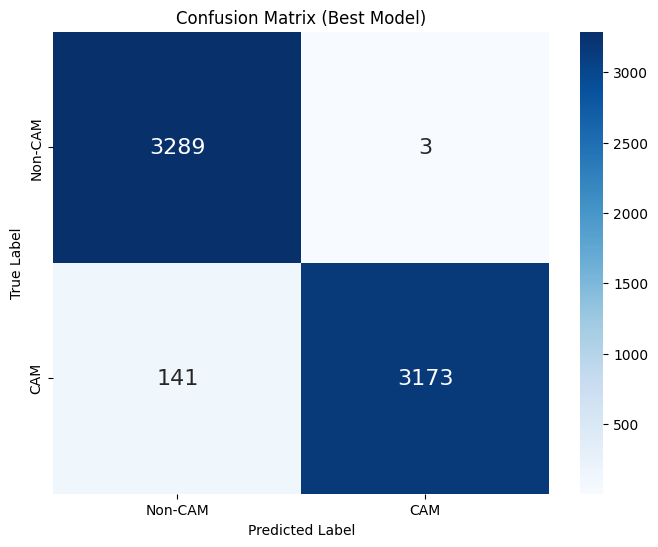


Classification Report (Best Model):

              precision    recall  f1-score   support

     Non-CAM       0.96      1.00      0.98      3292
         CAM       1.00      0.96      0.98      3314

    accuracy                           0.98      6606
   macro avg       0.98      0.98      0.98      6606
weighted avg       0.98      0.98      0.98      6606



In [26]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# Load the best model weights
print(f"Loading best model from {SAVE_PATH} (Epoch {best_epoch})")
checkpoint = torch.load(SAVE_PATH, weights_only=False)
model.load_state_dict(checkpoint['model_state'])
model.to(device)
model.eval()

# Get predictions from the BEST model
all_preds = []
all_labels = []

with torch.no_grad():
    for weak_imgs, _, labels, _ in tqdm(val_loader, desc="Generating Confusion Matrix"):
        imgs = weak_imgs.to(device)
        out = model(imgs)
        logits = out["logits"]
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = ['Non-CAM', 'CAM'] # Assuming 0=Non-CAM, 1=CAM

df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)

plt.figure(figsize=(8, 6))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})
plt.title('Confusion Matrix (Best Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('confusion_matrix.png')
plt.show()

# Optional: Print detailed classification report
print("\nClassification Report (Best Model):\n")
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

Extracting features for t-SNE: 100%|██████████| 826/826 [02:04<00:00,  6.63it/s]


Running t-SNE on 6606 samples...


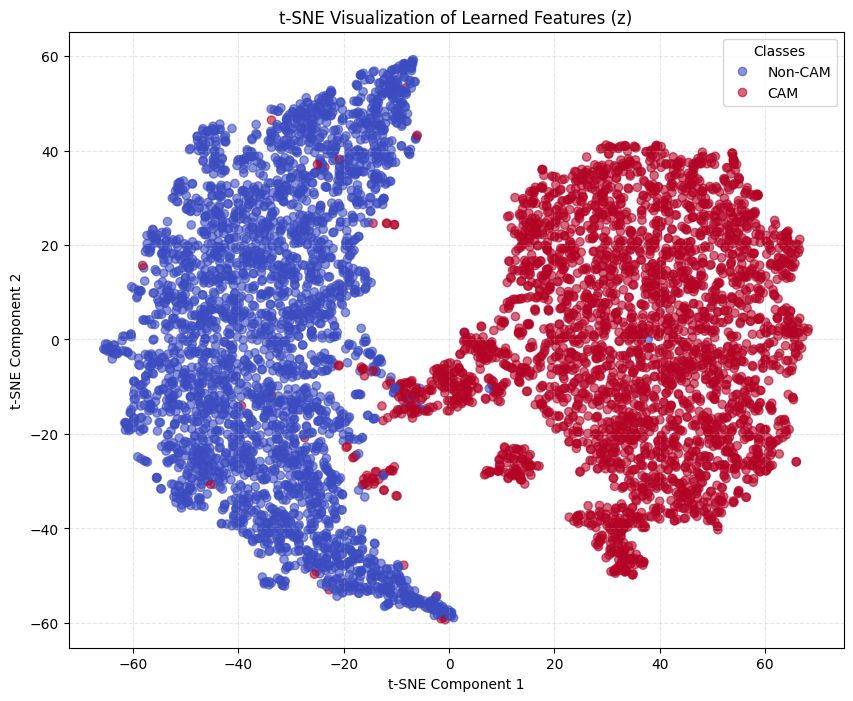

In [27]:
from sklearn.manifold import TSNE

# Get features (z) from the BEST model
all_feats = []
all_labels = []

model.eval()
with torch.no_grad():
    for weak_imgs, _, labels, _ in tqdm(val_loader, desc="Extracting features for t-SNE"):
        imgs = weak_imgs.to(device)
        out = model(imgs)
        all_feats.append(out["feat"].cpu())
        all_labels.append(labels.cpu())

all_feats = torch.cat(all_feats).numpy()
all_labels = torch.cat(all_labels).numpy()

print(f"Running t-SNE on {all_feats.shape[0]} samples...")
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
tsne_results = tsne.fit_transform(all_feats)

# Plot t-SNE
plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=all_labels, cmap='coolwarm', alpha=0.6)
plt.title('t-SNE Visualization of Learned Features (z)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
handles, _ = scatter.legend_elements()
plt.legend(handles, ['Non-CAM', 'CAM'], title='Classes')
plt.grid(True, linestyle='--', alpha=0.3)
plt.savefig('tsne_features.png')
plt.show()